# 03 - Cross-lingual MT augmentation → 8000-claim curated dataset

Takes the open-judged `records_open.parquet` (notebook 02, gpt-oss ensemble labels) and augments it
with **super-high-quality open machine translation** of the English claims into the target languages,
lifting the non-English (especially hallucination) share to a balanced 8000-claim curated dataset,
then joins the VitaminC public-benchmark slice. The pipeline is **frontier-free** - the translator is
the dedicated open NLLB-200 model, and translation fidelity is verified by back-translation + bge-m3
cosine (no Claude); the earlier Claude gold and Haiku-MT are kept only as reference.

**Approach** (each step reuses local open models on the RTX PRO 6000):
1. **Source** - English claims from `records_open` (both classes), split supported vs hallucination
2. **Translate** - NLLB-200-distilled-1.3B, English → 9 target languages, GPU-batched beam search
3. **Verify fidelity** - back-translate target → English, bge-m3 cosine ≥ threshold; a faithful
   translation of an `UNSUPPORTED` claim stays `UNSUPPORTED` against the same English evidence
4. **Assemble** - `records_open` + the verified MT (hallucination-heavy, balanced) capped to exactly
   8000, deduped by (claim, lang)
5. **Join VitaminC** - union the `eval_vitaminc` slice for the final benchmark-inclusive dataset

**Output** - `data/processed/dataset_pipeline/records_curated.parquet` (8000) and
`records_final.parquet` (8000 + VitaminC).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = os.environ.get("LLM_JUDGE_GPU", "GPU-a44e514a-aa5b-2844-35f1-4be28e1921e5")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

'1'

In [2]:
import json, gc, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModel
from transformers.utils import logging as _hf_logging
_hf_logging.disable_progress_bar(); _hf_logging.set_verbosity_error()
from rich import print as rprint
from rich.table import Table
from rich.progress import Progress, SpinnerColumn, BarColumn, TextColumn, MofNCompleteColumn, TimeElapsedColumn, TimeRemainingColumn
rprint("[dark_sea_green]✓[/dark_sea_green] imports")

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ imports

In [3]:
SEED = 20260705
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
rprint(f"[dark_sea_green]✓[/dark_sea_green] seed {SEED}")

✓ seed 20260705

## Configuration

Target languages match the reference augmentation (9 European incl. Nordic). The composition is
hallucination-heavy to lift that share while keeping some supported claims for realistic per-language
balance. Candidates are over-generated, fidelity-filtered, then sampled to hit exactly 8000.

In [4]:
DATA = Path("../../data")
OUT  = DATA / "processed" / os.environ.get("LLM_JUDGE_OUT", "dataset_pipeline")
RECORDS_OPEN = OUT / "records_open.parquet"
GOLD = DATA / "processed/golden_v5/golden_v5.parquet"

# NLLB-200 target languages (FLORES codes)
TGT_LANGS = {"es":"spa_Latn","fr":"fra_Latn","sv":"swe_Latn","nl":"nld_Latn","nb":"nob_Latn",
             "da":"dan_Latn","de":"deu_Latn","pt":"por_Latn","it":"ita_Latn"}
SRC_CODE = "eng_Latn"
MT_MODEL = "facebook/nllb-200-distilled-1.3B"

TARGET_TOTAL   = 8000        # curated dataset size before VitaminC
FIDELITY_THR   = float(os.environ.get("MT_FIDELITY_THR", "0.85"))  # min back-translation bge-m3 cosine
CAND_HALLUC    = int(os.environ.get("MT_CAND_HALLUC", "260"))  # english hallucination claims translated per language (pre-filter)
CAND_SUPP      = int(os.environ.get("MT_CAND_SUPP", "140"))    # english supported claims translated per language (pre-filter)
HALLUC_FRAC    = 0.66        # target hallucination fraction of the MT rows kept
NUM_BEAMS      = 4
MT_BATCH       = 24
EMB_BATCH      = 32
MAX_LEN        = 400

DEV = "cuda" if torch.cuda.is_available() else "cpu"

t = Table(title="03 - cross-lingual augmentation config", show_header=False)
t.add_row("Base", str(RECORDS_OPEN))
t.add_row("Translator", f"{MT_MODEL} (dedicated open MT)")
t.add_row("Target languages", " ".join(TGT_LANGS))
t.add_row("Target total", f"{TARGET_TOTAL} (+ VitaminC after)")
t.add_row("Fidelity gate", f"back-translate + bge-m3 cosine ≥ {FIDELITY_THR}")
t.add_row("Candidates/lang", f"{CAND_HALLUC} halluc + {CAND_SUPP} supported")
t.add_row("Device", torch.cuda.get_device_name(0) if DEV=="cuda" else "cpu")
rprint(t)

                     03 - cross-lingual augmentation config                      
┌──────────────────┬────────────────────────────────────────────────────────────┐
│ Base             │ ../../data/processed/dataset_pipeline/records_open.parquet │
│ Translator       │ facebook/nllb-200-distilled-1.3B (dedicated open MT)       │
│ Target languages │ es fr sv nl nb da de pt it                                 │
│ Target total     │ 8000 (+ VitaminC after)                                    │
│ Fidelity gate    │ back-translate + bge-m3 cosine ≥ 0.85                      │
│ Candidates/lang  │ 260 halluc + 140 supported                                 │
│ Device           │ NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition    │
└──────────────────┴────────────────────────────────────────────────────────────┘

## Base dataset and source claims

`records_open` is the frontier-free open-judged dataset. English claims are the translation source,
split by label so the augmentation can be composed hallucination-heavy but balanced.

In [5]:
ro = pd.read_parquet(RECORDS_OPEN)
en = ro[ro["lang"] == "en"].copy()
en_h = en[en["label"] == 0].reset_index(drop=True)   # hallucination source pool
en_s = en[en["label"] == 1].reset_index(drop=True)   # supported source pool
need = TARGET_TOTAL - len(ro)
rprint(f"[dark_sea_green]✓[/dark_sea_green] base [dark_sea_green]{len(ro)}[/dark_sea_green] "
       f"(en halluc {len(en_h)}, en supported {len(en_s)}); need [cadet_blue]{need}[/cadet_blue] verified MT rows to reach {TARGET_TOTAL}")

✓ base 5242 (en halluc 1776, en supported 2300); need 2758 verified MT rows to reach 8000

## Open MT + fidelity models

NLLB-200 for translation both directions; bge-m3 (CLS pooling, L2-normalised) for the back-translation
fidelity cosine. Both bf16 on the GPU.

In [6]:
rprint("[grey70]loading NLLB + bge-m3 ...[/grey70]")
_mt_tok = AutoTokenizer.from_pretrained(MT_MODEL)
_mt = AutoModelForSeq2SeqLM.from_pretrained(MT_MODEL, torch_dtype=torch.bfloat16).to(DEV).eval()
_emb_tok = AutoTokenizer.from_pretrained("BAAI/bge-m3")
_emb = AutoModel.from_pretrained("BAAI/bge-m3", torch_dtype=torch.bfloat16).to(DEV).eval()

def _tgt_id(code):
    tid = _mt_tok.convert_tokens_to_ids(code)
    if tid is None or tid == _mt_tok.unk_token_id:
        tid = getattr(_mt_tok, "lang_code_to_id", {}).get(code)
    return tid

@torch.no_grad()
def translate(texts, src, tgt):
    _mt_tok.src_lang = src; out = []
    fb = _tgt_id(tgt)
    for i in range(0, len(texts), MT_BATCH):
        enc = _mt_tok([str(x) for x in texts[i:i+MT_BATCH]], return_tensors="pt", padding=True,
                      truncation=True, max_length=MAX_LEN).to(DEV)
        g = _mt.generate(**enc, forced_bos_token_id=fb, max_length=MAX_LEN, num_beams=NUM_BEAMS)
        out += _mt_tok.batch_decode(g, skip_special_tokens=True)
    return out

@torch.no_grad()
def embed(texts):
    out = []
    for i in range(0, len(texts), EMB_BATCH):
        enc = _emb_tok([str(x) for x in texts[i:i+EMB_BATCH]], return_tensors="pt", padding=True,
                       truncation=True, max_length=512).to(DEV)
        h = _emb(**enc).last_hidden_state[:, 0]
        out.append(torch.nn.functional.normalize(h.float(), dim=-1).cpu().numpy())
    return np.vstack(out)
rprint("[dark_sea_green]✓[/dark_sea_green] MT + fidelity models loaded")

loading NLLB + bge-m3 ...

✓ MT + fidelity models loaded

## Translate and fidelity-filter

For each target language: sample a hallucination-heavy pool of English claims, translate, back-translate,
keep only translations whose back-translation cosine to the original clears the gate. The kept rows carry
the source label (a faithful translation preserves grounding), target language, and source `trace_id`.

In [7]:
def sample_pool(df, k):
    return df.sample(n=min(k, len(df)), random_state=SEED, replace=False)

_hb = open(Path("../../logs") / "augment-progress.log", "a", buffering=1)   # per-language heartbeat (nbconvert buffers cell stdout)
mt_rows = []
with Progress(SpinnerColumn(), TextColumn("[steel_blue]{task.description}"), BarColumn(bar_width=32),
              MofNCompleteColumn(), TimeElapsedColumn(), TimeRemainingColumn()) as prog:
    task = prog.add_task("translate+verify", total=len(TGT_LANGS))
    for li, (lang, code_) in enumerate(TGT_LANGS.items(), 1):
        kept_lang = 0
        for src_df, lab in [(en_h, 0), (en_s, 1)]:
            k = CAND_HALLUC if lab == 0 else CAND_SUPP
            pool = sample_pool(src_df, k)
            claims = pool["claim"].astype(str).tolist()
            fwd = translate(claims, SRC_CODE, code_)
            back = translate(fwd, code_, SRC_CODE)
            cos = (embed(claims) * embed(back)).sum(1)
            for c_orig, c_tr, cs, tid in zip(claims, fwd, cos, pool["trace_id"].tolist()):
                if cs >= FIDELITY_THR and len(c_tr.strip()) >= 3:
                    mt_rows.append({"claim": c_tr, "label": lab, "lang": lang, "trace_id": tid,
                                    "origin": "open_mt_nllb", "src_lang": "en", "fidelity": float(cs)})
                    kept_lang += 1
        _hb.write(f"lang {li}/{len(TGT_LANGS)} {lang}: kept {kept_lang}, total verified {len(mt_rows)}\n")
        prog.advance(task)
_hb.close()
mt = pd.DataFrame(mt_rows).drop_duplicates(subset=["claim", "trace_id", "lang"]).reset_index(drop=True)
rprint(f"[dark_sea_green]✓[/dark_sea_green] verified MT rows: [dark_sea_green]{len(mt)}[/dark_sea_green] "
       f"(halluc {int((mt.label==0).sum())} / supported {int((mt.label==1).sum())}); "
       f"mean fidelity {mt.fidelity.mean():.3f}")

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/lab/.venvs/groundrails-judge/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ verified MT rows: 3363 (halluc 2235 / supported 1128); mean fidelity 0.955

## Assemble the 8000-claim curated dataset

Sample the verified MT rows to exactly `TARGET_TOTAL - len(records_open)`, hallucination-heavy per
`HALLUC_FRAC`, spread across languages, then union with the base and dedupe.

In [8]:
KEY = ["claim", "trace_id", "lang"]
COLS = ["claim", "label", "lang", "trace_id", "origin", "src_lang", "fidelity"]
base = ro.assign(src_lang=np.nan, fidelity=np.nan)
# verified MT that does not collide with a base row on (claim, trace_id, lang)
mtv = mt.merge(base[KEY], on=KEY, how="left", indicator=True)
mtv = mtv[mtv["_merge"] == "left_only"].drop(columns="_merge").reset_index(drop=True)
# sample exactly `need`, hallucination-heavy per HALLUC_FRAC
n_h = int(round(need * HALLUC_FRAC)); n_s = need - n_h
mh = mtv[mtv.label == 0]; ms = mtv[mtv.label == 1]
add = pd.concat([mh.sample(n=min(n_h, len(mh)), random_state=SEED),
                 ms.sample(n=min(n_s, len(ms)), random_state=SEED)])
if len(add) < need:                       # top up from remaining verified rows
    rest = mtv.loc[~mtv.index.isin(add.index)]
    add = pd.concat([add, rest.sample(n=min(need - len(add), len(rest)), random_state=SEED)])
add = add.head(need)

curated = pd.concat([base[COLS], add[COLS]], ignore_index=True)   # exactly len(base)+need = 8000 if MT sufficient
curated.to_parquet(OUT / "records_curated.parquet")
if len(curated) < TARGET_TOTAL:
    rprint(f"[dark_goldenrod]⚠[/dark_goldenrod] only {len(curated)} (< {TARGET_TOTAL}) - verified MT pool short by {TARGET_TOTAL-len(curated)}; raise MT_CAND_* and re-run")
rprint(f"[dark_sea_green]✓[/dark_sea_green] wrote [dark_sea_green]{len(curated)}[/dark_sea_green] -> records_curated.parquet "
       f"(supported {int((curated.label==1).sum())} / hallucination {int((curated.label==0).sum())})")

✓ wrote 8000 -> records_curated.parquet (supported 4278 / hallucination 3722)

## Join VitaminC

Union the `eval_vitaminc` public-benchmark slice (already gold-labeled) onto the curated set for the
final benchmark-inclusive dataset.

In [9]:
g = pd.read_parquet(GOLD)
vc = g[g["role"] == "eval_vitaminc"].copy()
vc_rows = vc[["claim","label","lang_norm","trace_id"]].rename(columns={"lang_norm":"lang"}).copy()  # select lang_norm first - golden_v5 also has a 'lang' col
vc_rows["origin"] = "vitaminc"; vc_rows["src_lang"] = np.nan; vc_rows["fidelity"] = np.nan
final = pd.concat([curated, vc_rows], ignore_index=True).drop_duplicates(subset=["claim","trace_id","lang"]).reset_index(drop=True)
final.to_parquet(OUT / "records_final.parquet")
rprint(f"[dark_sea_green]✓[/dark_sea_green] wrote [dark_sea_green]{len(final)}[/dark_sea_green] -> records_final.parquet "
       f"(curated {len(curated)} + VitaminC {len(vc_rows)})")

✓ wrote 8796 -> records_final.parquet (curated 8000 + VitaminC 800)

## Summary

Language × label distribution of the curated 8000 and the VitaminC-joined final set.

           records_curated (8000)           
┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ lang ┃ total ┃ supported ┃ hallucination ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ en   │ 4076  │ 2300      │ 1776          │
│ fr   │ 710   │ 472       │ 238           │
│ nb   │ 560   │ 332       │ 228           │
│ es   │ 525   │ 289       │ 236           │
│ it   │ 420   │ 213       │ 207           │
│ pt   │ 359   │ 142       │ 217           │
│ nl   │ 339   │ 141       │ 198           │
│ sv   │ 330   │ 113       │ 217           │
│ de   │ 316   │ 115       │ 201           │
│ da   │ 309   │ 118       │ 191           │
│ nn   │ 18    │ 16        │ 2             │
│ und  │ 14    │ 11        │ 3             │
│ la   │ 12    │ 8         │ 4             │
│ eo   │ 3     │ 2         │ 1             │
└──────┴───────┴───────────┴───────────────┘

hallucination share: base 36% -> curated 47%

non-English share: base 22% -> curated 49%

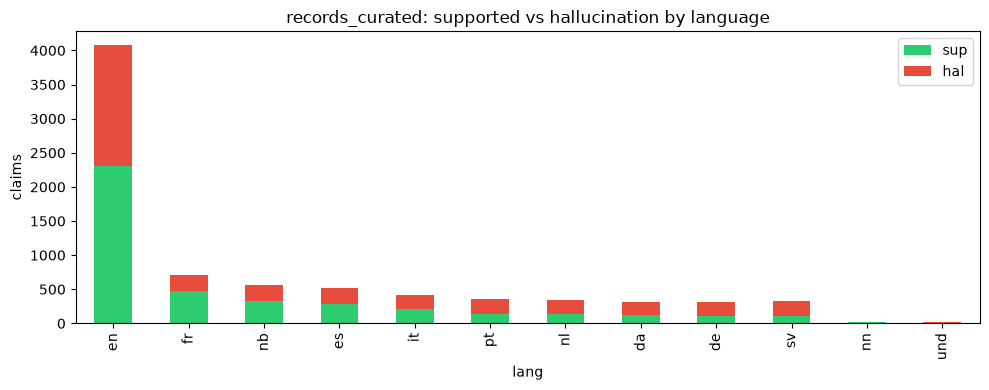

In [10]:
def dist(df, title):
    tab = Table(title=title)
    for c in ("lang","total","supported","hallucination"): tab.add_column(c)
    d = df.groupby("lang")["label"].agg(total="size", sup=lambda s:(s==1).sum(), hal=lambda s:(s==0).sum()).sort_values("total", ascending=False)
    for lg, r in d.head(14).iterrows():
        tab.add_row(lg, str(int(r.total)), str(int(r.sup)), str(int(r.hal)))
    rprint(tab)
dist(curated, "records_curated (8000)")
rprint(f"[bold]hallucination share[/bold]: base {(ro.label==0).mean():.0%} -> curated {(curated.label==0).mean():.0%}")
rprint(f"[bold]non-English share[/bold]: base {(ro.lang!='en').mean():.0%} -> curated {(curated.lang!='en').mean():.0%}")

import matplotlib.pyplot as plt
d = curated.groupby("lang")["label"].agg(sup=lambda s:(s==1).sum(), hal=lambda s:(s==0).sum()).sort_values("sup", ascending=False).head(12)
ax = d.plot(kind="bar", stacked=True, figsize=(10,4), color=["#2ECC71","#E74C3C"])
ax.set_title("records_curated: supported vs hallucination by language"); ax.set_ylabel("claims"); plt.tight_layout(); plt.show()